In [9]:
import os
import pandas as pd
import numpy as np
from collections import Counter
from sklearn.ensemble import RandomForestClassifier
from scipy.signal import medfilt 
import scipy.ndimage
from scipy.ndimage import median_filter
import random
import matplotlib.pyplot as plt
import csv


# Normal Median Filtered Histogram 

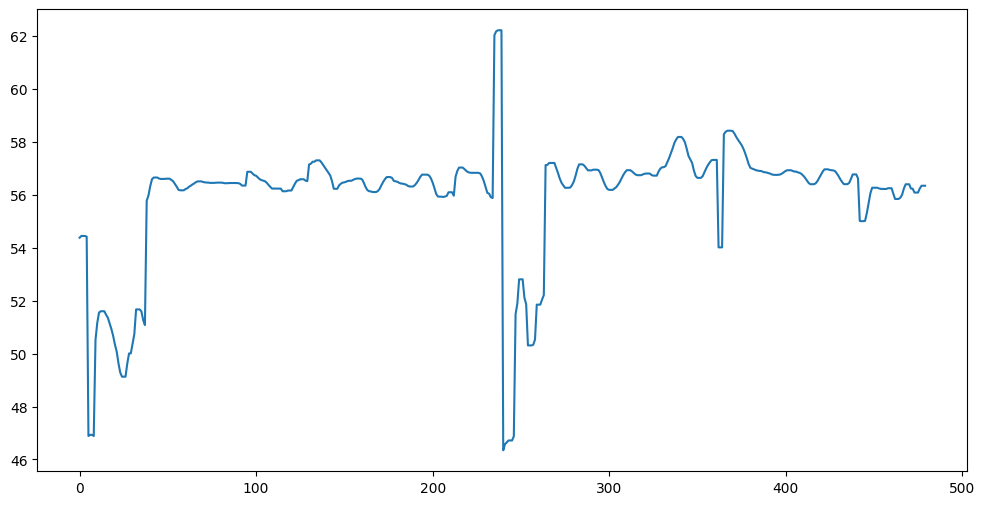

In [3]:
def f0_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

def apply_median_filter(f0_series, kernel_size=5):
    f0_series = np.where(np.isnan(f0_series), 0, f0_series)
    filtered_f0 = medfilt(f0_series, kernel_size = kernel_size)
    filtered_f0[filtered_f0 == 0] = np.nan
    return filtered_f0

file_path =  '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/F0/박봉술 춘향가 천자뒤풀이 김명환_3.csv'
df = pd.read_csv(file_path, header = None)

df.columns = ['Time', 'F0', 'Confidence']
df.loc[df['Confidence'] <= 0.7, "F0"] = np.nan
f0_values = apply_median_filter(df["F0"].values)
valid_f0_values = f0_values[~np.isnan(f0_values)]
midi_notes = f0_to_midi(valid_f0_values) 

lower_bound = 41
upper_bound = 72

midi_notes = [x for x in midi_notes if lower_bound <= x < upper_bound]

plt.figure(figsize=(12, 6))
plt.plot(midi_notes)
plt.show()

Normalized Pitch Histogram: [0.         0.         0.02291667 0.         0.         0.0125
 0.02916667 0.04166667 0.0125     0.         0.02083333 0.04166667
 0.67291667 0.10625    0.02916667 0.         0.         0.
 0.01041667 0.         0.         0.         0.         0.
 0.        ]


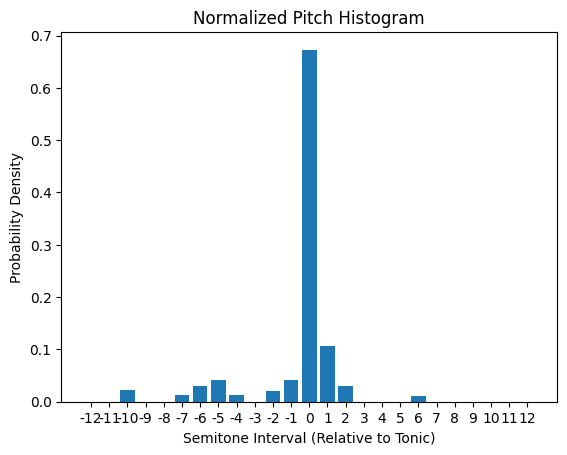

In [4]:
def get_norm_pitch_histogram(midi_contour, compensate_tuning = True):
    edge = [i + (-12.5) for i in range(26)]
    max_appearance = 0
    comp = 0
    final_common_midi = 0
    if compensate_tuning:
        for compensate in (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9):
            intmidi = [round(midi + compensate) for midi in midi_contour]
            common_pitch, num_appearance = Counter(intmidi).most_common()[0]
            if max_appearance <= num_appearance:
                max_appearance = num_appearance
                comp = compensate
                final_common_midi = common_pitch 
    norm_midi = [midi-float(final_common_midi-comp) for midi in midi_contour]
    mono_hist = np.histogram(norm_midi, bins = edge, density=True)
    return mono_hist[0]

test = get_norm_pitch_histogram(midi_notes)

print("Normalized Pitch Histogram:", test)

plt.bar(range(len(test)), test, tick_label=[f"{-12 + i}" for i in range(25)])
plt.xlabel("Semitone Interval (Relative to Tonic)")
plt.ylabel("Probability Density")
plt.title("Normalized Pitch Histogram")
plt.show()

# Morphological Histogram

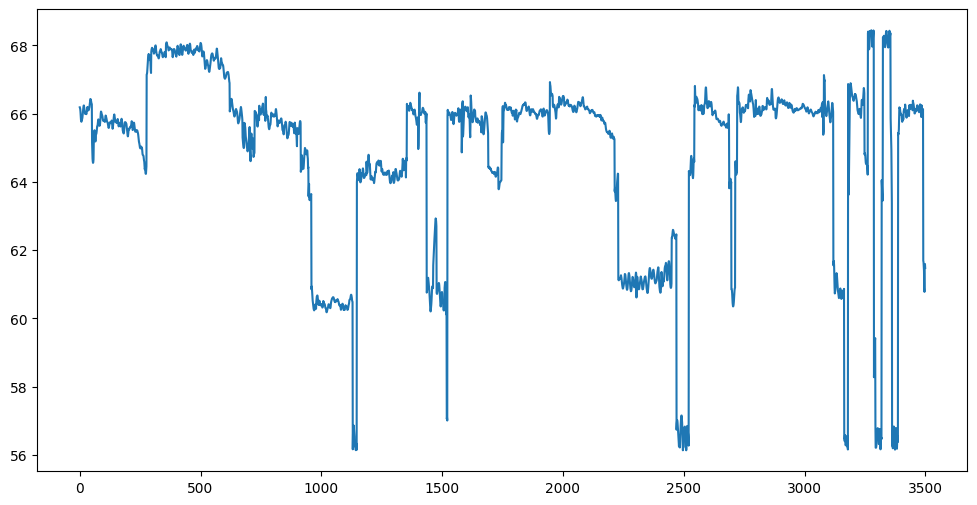

In [5]:
def f0_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

def apply_median_filter(f0_series, kernel_size=5):
    f0_series = np.where(np.isnan(f0_series), 0, f0_series)
    filtered_f0 = medfilt(f0_series, kernel_size = kernel_size)
    filtered_f0[filtered_f0 == 0] = np.nan
    return filtered_f0

file_path =  '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/morph_filtered.csv'
df = pd.read_csv(file_path, header = None)

df.columns = ['F0', 'Time']
f0_values = df["F0"].values
valid_f0_values = f0_values[~np.isnan(f0_values)]
midi_notes = f0_to_midi(valid_f0_values) 

lower_bound = 41
upper_bound = 72

midi_notes = [x for x in midi_notes if lower_bound <= x < upper_bound]

plt.figure(figsize=(12, 6))
plt.plot(midi_notes)
plt.show()

Normalized Pitch Histogram: [0.00000000e+00 0.00000000e+00 1.42857143e-02 2.51428571e-02
 2.85714286e-04 1.14285714e-03 2.88571429e-02 1.12857143e-01
 1.42857143e-02 6.00000000e-03 8.17142857e-02 6.71428571e-02
 4.97142857e-01 5.20000000e-02 9.54285714e-02 3.71428571e-03
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


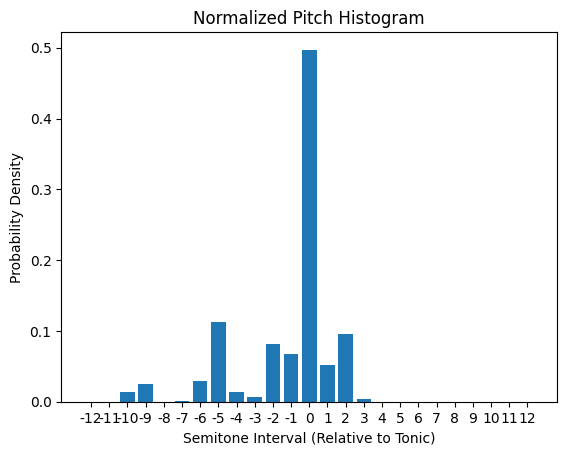

In [6]:
def get_norm_pitch_histogram(midi_contour, compensate_tuning = True):
    edge = [i + (-12.5) for i in range(26)]
    max_appearance = 0
    comp = 0
    final_common_midi = 0
    if compensate_tuning:
        for compensate in (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9):
            intmidi = [round(midi + compensate) for midi in midi_contour]
            common_pitch, num_appearance = Counter(intmidi).most_common()[0]
            if max_appearance <= num_appearance:
                max_appearance = num_appearance
                comp = compensate
                final_common_midi = common_pitch 
    norm_midi = [midi-float(final_common_midi-comp) for midi in midi_contour]
    mono_hist = np.histogram(norm_midi, bins = edge, density=True)
    return mono_hist[0]

test = get_norm_pitch_histogram(midi_notes)

print("Normalized Pitch Histogram:", test)

plt.bar(range(len(test)), test, tick_label=[f"{-12 + i}" for i in range(25)])
plt.xlabel("Semitone Interval (Relative to Tonic)")
plt.ylabel("Probability Density")
plt.title("Normalized Pitch Histogram")
plt.show()

# Mask Filtered Histogram

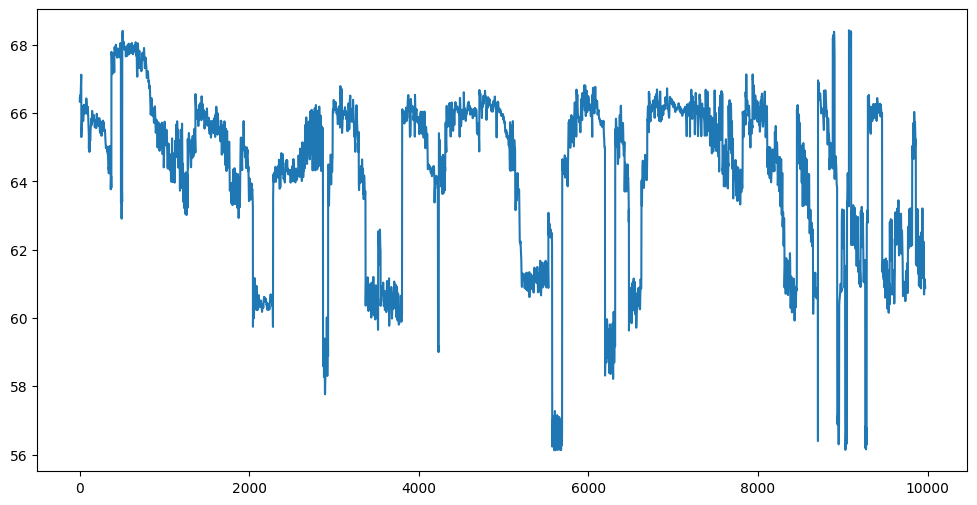

In [7]:
def f0_to_midi(frequency):
    return 69 + 12 * np.log2(frequency / 440)

def apply_median_filter(f0_series, kernel_size=5):
    f0_series = np.where(np.isnan(f0_series), 0, f0_series)
    filtered_f0 = medfilt(f0_series, kernel_size = kernel_size)
    filtered_f0[filtered_f0 == 0] = np.nan
    return filtered_f0

file_path =  '/home/sangheon/Desktop/Pansori_2025_ISMIR/PansoriData/mask_filtered.csv'
df = pd.read_csv(file_path, header = None)

df.columns = ['F0', 'Time']
f0_values = df["F0"].values
valid_f0_values = f0_values[~np.isnan(f0_values)]
midi_notes = f0_to_midi(valid_f0_values) 

lower_bound = 41
upper_bound = 72

midi_notes = [x for x in midi_notes if lower_bound <= x < upper_bound]

plt.figure(figsize=(12, 6))
plt.plot(midi_notes)
plt.show()

Normalized Pitch Histogram: [0.00000000e+00 0.00000000e+00 4.21137070e-03 1.39376316e-02
 1.70460243e-03 1.24335706e-02 3.79023363e-02 1.15912965e-01
 3.80026070e-02 4.15120826e-02 1.31454928e-01 1.58628296e-01
 3.59069488e-01 4.51218289e-02 3.99077509e-02 2.00541462e-04
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


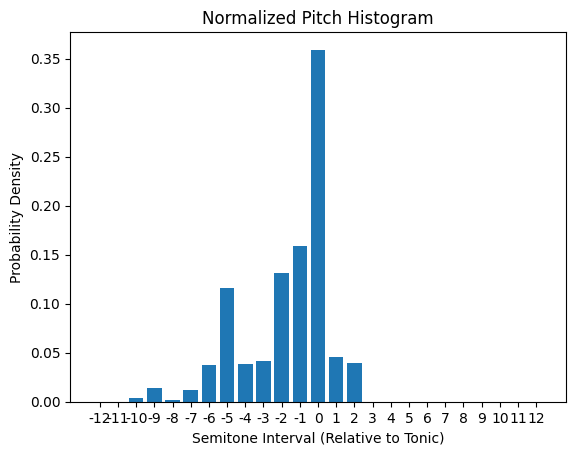

In [8]:
def get_norm_pitch_histogram(midi_contour, compensate_tuning = True):
    edge = [i + (-12.5) for i in range(26)]
    max_appearance = 0
    comp = 0
    final_common_midi = 0
    if compensate_tuning:
        for compensate in (0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9):
            intmidi = [round(midi + compensate) for midi in midi_contour]
            common_pitch, num_appearance = Counter(intmidi).most_common()[0]
            if max_appearance <= num_appearance:
                max_appearance = num_appearance
                comp = compensate
                final_common_midi = common_pitch 
    norm_midi = [midi-float(final_common_midi-comp) for midi in midi_contour]
    mono_hist = np.histogram(norm_midi, bins = edge, density=True)
    return mono_hist[0]

test = get_norm_pitch_histogram(midi_notes)

print("Normalized Pitch Histogram:", test)

plt.bar(range(len(test)), test, tick_label=[f"{-12 + i}" for i in range(25)])
plt.xlabel("Semitone Interval (Relative to Tonic)")
plt.ylabel("Probability Density")
plt.title("Normalized Pitch Histogram")
plt.show()